# From newsvendor to the full controller

This notebook walks from the classic **newsvendor** idea to the **production controller**
that runs in the Rust kernel (`blueberries_voi._core`). Each step adds one real-world
complication that blueberry stores face:

1. **Newsvendor** — how much to order when leftover stock has a cost.
2. **Base-stock** — keep a target level of inventory and top up when low.
3. **Protection interval** — under Mon/Wed/Fri delivery, the target covers several days.
4. **Effective inventory** — count berries by how likely they are still alive.
5. **Policy ladder** — age-blind correction → survival-weighted → rollout lookahead.
6. **EngineSession** — the full closed-loop controller in Rust.

The demos use the installed `blueberries_voi` package. Simulation-heavy cells call
`EngineSession.act()` so the hot path stays in the PyO3 module.

## Setup

From the repo root (with the Rust extension built):

```bash
uv sync --all-extras --python 3.11
uv run --python 3.11 maturin develop --release -m crates/voi_py/Cargo.toml
export BLUEBERRIES_VOI_BACKEND=rust
uv run jupyter lab notebooks/
```

In [1]:
%matplotlib inline

from __future__ import annotations

import os
from datetime import date, timedelta
from types import SimpleNamespace

os.environ.setdefault("BLUEBERRIES_VOI_BACKEND", "rust")

import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import nbinom

from blueberries_voi.backend import rust_available, warn_fallback_once
from blueberries_voi.controller.rung0 import CorrectedAgeBlindPolicy
from blueberries_voi.filter.belief import (
    ShelfBelief,
    effective_inventory,
    shelf_belief_from_oracle,
)
from blueberries_voi.model import ModelParams
from blueberries_voi.sim.bakeoff_damped_sw import (
    DampedSurvivalWeightedPolicy,
    protection_demand_quantile,
)
from blueberries_voi.sim.open_loop import open_loop_order
from blueberries_voi.sim.order_schedule import DEFAULT_ORDER_SCHEDULE
from blueberries_voi.sim.profit import DEFAULT_PROFIT_COSTS, day_profit
from blueberries_voi.sim.shipments import smoke_cool_shipments
from blueberries_voi.simulator import DEMO_BUDGETS, EngineSession

plt.rcParams.update({"figure.figsize": (8, 4.5), "axes.grid": True, "grid.alpha": 0.3})

warn_fallback_once()
if not rust_available():
    raise RuntimeError(
        "Rust kernel required. Build with:\n"
        "  uv run maturin develop --release -m crates/voi_py/Cargo.toml"
    )

params = ModelParams()
schedule = DEFAULT_ORDER_SCHEDULE
EPOCH = date(2024, 1, 1)
WEEKDAY = ["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"]

print(f"Defaults: μ={params.demand_mu}, case_size={params.case_size}, β={params.beta}")
print(f"Rust backend: {rust_available()}")

Defaults: μ=30.0, case_size=8, β=2.0
Rust backend: True


## 1. The newsvendor problem

Imagine you order **one batch** of berries for tomorrow. Demand is random. If you
order too little you lose sales; if you order too much you may waste what is left.

With unit margin `c_s` (profit on a sold unit) and waste cost `c_w` (cost of a spoiled
unit), the classic **critical fractile** is:

$$\alpha^\* = \frac{c_s}{c_s + c_w}$$

Order the demand quantile at that level: find `d` such that
`P(Demand ≤ d) = α*`.

Below we plot daily demand (negative binomial with store defaults) and mark the
textbook fractile. This is a useful **mental model**, not the number our controller
uses directly — see §3.

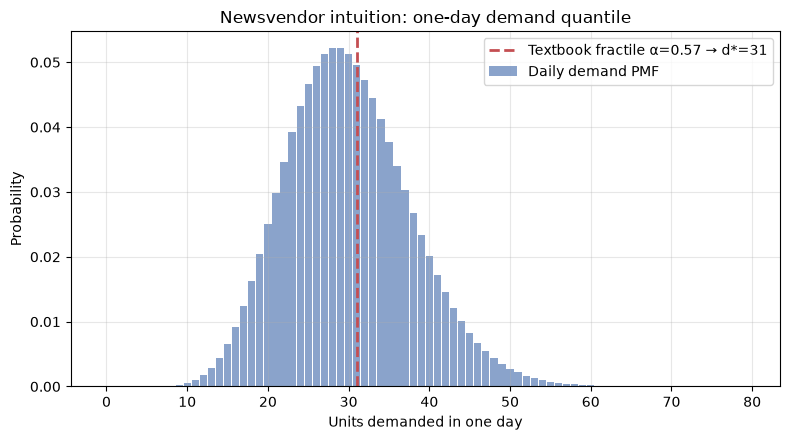

Unit margin=2.0, waste cost=1.5
Textbook α* = 0.571, one-day target d* ≈ 31


In [2]:
costs = DEFAULT_PROFIT_COSTS
alpha_textbook = costs.unit_margin / (costs.unit_margin + costs.waste_cost)

r = params.nb_r()
p = params.nb_p()
x = np.arange(0, 80)
pmf = nbinom.pmf(x, r, p)
cdf = nbinom.cdf(x, r, p)
d_star_1day = float(nbinom.ppf(alpha_textbook, r, p))

fig, ax = plt.subplots()
ax.bar(x, pmf, width=0.9, alpha=0.65, color="#4C72B0", label="Daily demand PMF")
ax.axvline(d_star_1day, color="#C44E52", ls="--", lw=2,
           label=f"Textbook fractile α={alpha_textbook:.2f} → d*={d_star_1day:.0f}")
ax.set_xlabel("Units demanded in one day")
ax.set_ylabel("Probability")
ax.set_title("Newsvendor intuition: one-day demand quantile")
ax.legend()
fig.tight_layout()
plt.show()

print(f"Unit margin={costs.unit_margin}, waste cost={costs.waste_cost}")
print(f"Textbook α* = {alpha_textbook:.3f}, one-day target d* ≈ {d_star_1day:.0f}")

## 2. Base-stock policy (naive)

A **base-stock** policy keeps a target level `S` on the shelf. Each day:

$$q_t = \max(0,\; S - I_t)$$

where `I_t` is on-hand inventory. Our M1 open-loop helper uses a fixed `S=60` and
ignores age, pipeline, and the order calendar:

```python
open_loop_order(on_hand, S=60)  # sim/open_loop.py
```

The chart shows how orders react as on-hand drifts below the target.

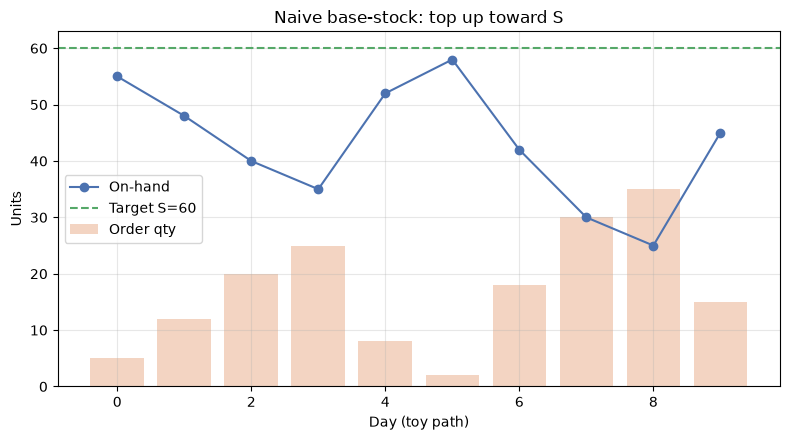

In [3]:
S_NAIVE = 60
on_hand_path = [55, 48, 40, 35, 52, 58, 42, 30, 25, 45]
orders = [open_loop_order(i, S=S_NAIVE) for i in on_hand_path]

fig, ax = plt.subplots()
days = np.arange(len(on_hand_path))
ax.plot(days, on_hand_path, "o-", label="On-hand", color="#4C72B0")
ax.axhline(S_NAIVE, color="#55A868", ls="--", label=f"Target S={S_NAIVE}")
ax.bar(days, orders, alpha=0.35, color="#DD8452", label="Order qty")
ax.set_xlabel("Day (toy path)")
ax.set_ylabel("Units")
ax.set_title("Naive base-stock: top up toward S")
ax.legend()
fig.tight_layout()
plt.show()

## 3. Why we do not use the textbook fractile

Blueberries are **not** a single-period newsvendor problem:

- Unsold berries can sell on later days (not instant waste).
- Orders happen on **Sun / Tue / Thu** and must cover until the next delivery.
- Shelf age and spoilage matter.

So we pick a service level `α` by **simulation** (closed-loop profit), not
`c_s/(c_s+c_w)` alone (ADR 0060). The protection target is still a demand quantile —
but over **several days** of demand:

```python
protection_demand_quantile(alpha, params, protection_days=n)
```

The chart contrasts the textbook one-day fractile with a tuned `α=0.9` over a
3-day protection window (Sunday order day).

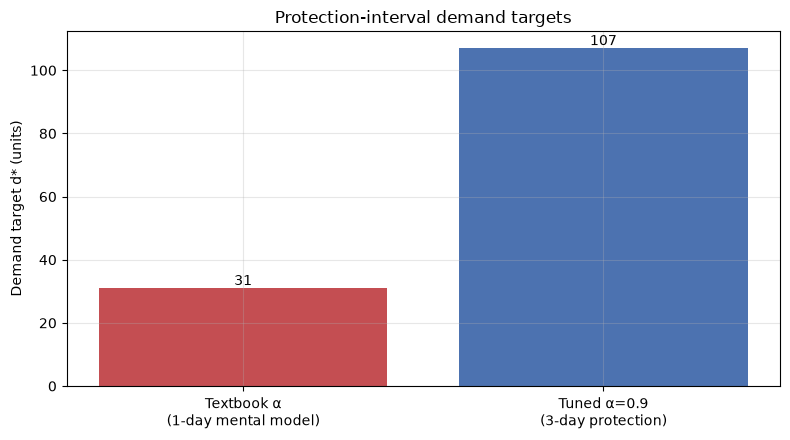

Sunday protection_days=3
  textbook 1-day d* ≈ 31
  tuned 3-day d* ≈ 107


In [4]:
ALPHA_TUNED = 0.9
prot_sun = schedule.protection_days(6)  # epoch day 6 = Sunday

d_textbook = protection_demand_quantile(alpha_textbook, params, protection_days=prot_sun)
d_tuned = protection_demand_quantile(ALPHA_TUNED, params, protection_days=prot_sun)

labels = ["Textbook α\n(1-day mental model)", f"Tuned α={ALPHA_TUNED}\n({prot_sun}-day protection)"]
vals = [
    float(nbinom.ppf(alpha_textbook, params.nb_r(), params.nb_p())),
    d_tuned,
]

fig, ax = plt.subplots()
ax.bar(labels, vals, color=["#C44E52", "#4C72B0"])
ax.set_ylabel("Demand target d* (units)")
ax.set_title("Protection-interval demand targets")
for i, v in enumerate(vals):
    ax.text(i, v + 1, f"{v:.0f}", ha="center")
fig.tight_layout()
plt.show()

print(f"Sunday protection_days={prot_sun}")
print(f"  textbook 1-day d* ≈ {vals[0]:.0f}")
print(f"  tuned {prot_sun}-day d* ≈ {d_tuned:.0f}")

## 4. MWF calendar and protection length

Trucks deliver **Mon / Wed / Fri**. The store orders **Sun / Tue / Thu** with
lead time 1 day. On each order day the controller targets enough stock to cover
until the **next** order:

| Order day | Protection days |
|-----------|-----------------|
| Sunday    | 3 |
| Tuesday   | 3 |
| Thursday  | 4 |

Non-order days return **zero** cases. `OrderSchedule` encodes this rhythm.

Order days in first two weeks:
  day  1 (Tue): protection=3
  day  3 (Thu): protection=4
  day  6 (Sun): protection=3
  day  8 (Tue): protection=3
  day 10 (Thu): protection=4
  day 13 (Sun): protection=3


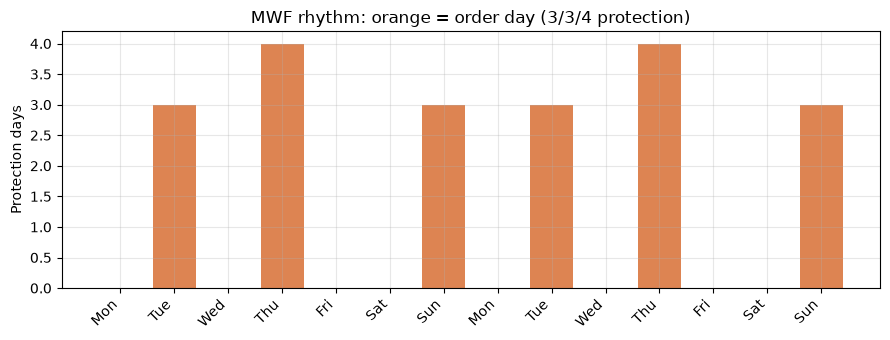

In [5]:
rows = []
for day in range(14):
    wd = WEEKDAY[(EPOCH + timedelta(days=day)).weekday()]
    rows.append({
        "day": day,
        "weekday": wd,
        "can_order": schedule.can_order(day),
        "protection": schedule.protection_days(day),
    })

order_days = [r for r in rows if r["can_order"]]
print("Order days in first two weeks:")
for r in order_days:
    print(f"  day {r['day']:2d} ({r['weekday']}): protection={r['protection']}")

fig, ax = plt.subplots(figsize=(9, 3.5))
xs = [r["day"] for r in rows]
heights = [r["protection"] if r["can_order"] else 0 for r in rows]
colors = ["#DD8452" if r["can_order"] else "#CCCCCC" for r in rows]
ax.bar(xs, heights, color=colors)
ax.set_xticks(xs, [r["weekday"] for r in rows], rotation=45, ha="right")
ax.set_ylabel("Protection days")
ax.set_title("MWF rhythm: orange = order day (3/3/4 protection)")
fig.tight_layout()
plt.show()

## 5. Effective inventory Ĩ

A naive count `Σ n_ℓ` treats every berry equally. **Effective inventory** discounts
each lot by how likely its berries are still alive when demand arrives, then adds
pipeline units with an expected survival weight.

$$	ilde I_t = \sum_\ell n_\ell \, \mathbb E[S(\tau_\ell)] + \text{pipeline}$$

When the shelf is young, naive and effective counts are close. With old lots,
effective inventory is much lower — so the controller orders more aggressively.

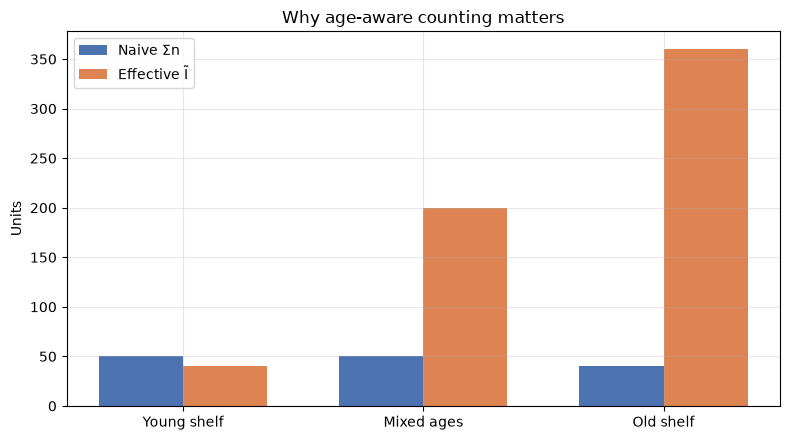

In [6]:
def make_belief(lot_counts: list[int], ages: list[float]) -> ShelfBelief:
    grid = [float(x) for x in range(0, 15, 2)]
    margs: list[list[float]] = []
    for age in ages:
        row = [0.0] * len(grid)
        idx = min(range(len(grid)), key=lambda i: abs(grid[i] - age))
        row[idx] = 1.0
        margs.append(row)
    return shelf_belief_from_oracle(
        lot_counts=lot_counts, f_marginals=margs, f_grid=grid
    )


def compare_inventory(label: str, lots: list[int], ages: list[float]) -> dict:
    belief = make_belief(lots, ages)
    naive = float(sum(lots))
    eff = effective_inventory(belief, pending_orders={})
    return {"label": label, "naive": naive, "effective": eff}


scenarios = [
    compare_inventory("Young shelf", [30, 20], [0.0, 2.0]),
    compare_inventory("Mixed ages", [25, 25], [0.0, 8.0]),
    compare_inventory("Old shelf", [20, 20], [8.0, 10.0]),
]

labels = [s["label"] for s in scenarios]
naive_v = [s["naive"] for s in scenarios]
eff_v = [s["effective"] for s in scenarios]
x = np.arange(len(labels))
w = 0.35

fig, ax = plt.subplots()
ax.bar(x - w / 2, naive_v, w, label="Naive Σn", color="#4C72B0")
ax.bar(x + w / 2, eff_v, w, label="Effective Ĩ", color="#DD8452")
ax.set_xticks(x, labels)
ax.set_ylabel("Units")
ax.set_title("Why age-aware counting matters")
ax.legend()
fig.tight_layout()
plt.show()

## 6. Rung 0 — corrected age-blind base-stock

Before age-aware policies, we need an honest **age-blind** competitor. Rung 0 sees
only **total on-hand** (not lot ages), applies a mean-survival correction, then
base-stock ordering:

$$q = \mathrm{caseRound}\big(\rho\,[d^\star - I^{R0}]^+\big)$$

`CorrectedAgeBlindPolicy` lives in `controller/rung0.py`. It is the bridge between
naive counting and survival-weighted control.

In [7]:
day = 6  # Sunday order day
prot = schedule.protection_days(day)
d_star = protection_demand_quantile(ALPHA_TUNED, params, protection_days=prot)

rung0 = CorrectedAgeBlindPolicy(
    alpha=ALPHA_TUNED,
    params=params,
    demand_target=d_star,
    schedule=schedule,
    rho=1.0,
)

fixtures = [
    ([40.0], {}, "N=40"),
    ([40.0], {1: 16}, "N=40 + pipeline 16"),
    ([], {}, "Empty"),
    ([100.0], {}, "Overstocked"),
]

print(f"Rung 0 on order day {day} (protection={prot}, d*={d_star:.0f})")
for lots, pending, label in fixtures:
    if lots:
        belief = make_belief([int(x) for x in lots], [0.0] * len(lots))
    else:
        belief = make_belief([0], [0.0])
    q = rung0.order(day, belief, pending_orders=pending)
    print(f"  {label:22s}  q={q:3d}")

Rung 0 on order day 6 (protection=3, d*=107)
  N=40                    q= 80
  N=40 + pipeline 16      q= 64
  Empty                   q=104
  Overstocked             q= 32


## 7. Damped survival-weighted base-stock (CTL-01)

The production base-stock rule uses **effective inventory** and Nahmias damping `ρ`:

$$q_t = \mathrm{caseRound}\big(\rho\,[F^{-1}_{D}(\alpha) - \tilde I_t]^+\big)$$

Default `ρ=0.8` avoids over-ordering when estimates are noisy. The chart shows how
order quantity falls as effective inventory rises (Sunday order, fresh vs stale mix).

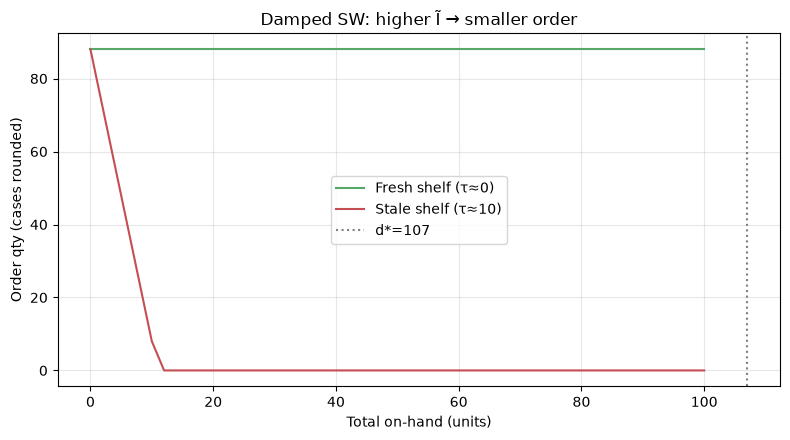

In [8]:
sw = DampedSurvivalWeightedPolicy(
    alpha=ALPHA_TUNED, rho=0.8, params=params, schedule=schedule
)

inv_grid = np.linspace(0, 100, 51)
orders_fresh = []
orders_stale = []
for inv in inv_grid:
    # Fresh: effective ≈ on-hand
    belief_f = make_belief([int(inv)], [0.0])
    orders_fresh.append(sw.order(belief_f, day=day))
    # Stale: effective < on-hand
    belief_s = make_belief([int(inv)], [10.0])
    orders_stale.append(sw.order(belief_s, day=day))

fig, ax = plt.subplots()
ax.plot(inv_grid, orders_fresh, label="Fresh shelf (τ≈0)", color="#55A868")
ax.plot(inv_grid, orders_stale, label="Stale shelf (τ≈10)", color="#C44E52")
ax.axvline(d_star, color="gray", ls=":", label=f"d*={d_star:.0f}")
ax.set_xlabel("Total on-hand (units)")
ax.set_ylabel("Order qty (cases rounded)")
ax.set_title("Damped SW: higher Ĩ → smaller order")
ax.legend()
fig.tight_layout()
plt.show()

## 8. The policy ladder

The controller is not one formula — it is a **ladder** of policies, each adding
structure:

| Step | Policy | What it knows |
|------|--------|----------------|
| 0 | Constant order | Fixed case qty |
| 1 | Rung 0 | Total on-hand + pipeline correction |
| 2 | Damped SW | Age-aware Ĩ + ρ damping |
| 3 | Rollout | One-step lookahead around SW base |
| 4 | Toy DP | Exact optimum on a tiny grid (certificate only) |

In production, `EngineSession.act(policy=...)` dispatches to Rust (`"constant"`,
`"damped_sw"` / `"sw"`, `"rollout"`). The next section runs a week in the kernel.

## 9. Full controller — `EngineSession` (Rust)

`EngineSession` is the interactive façade used by notebooks and the Studio UI.
Each `act()` call:

1. Updates the particle filter belief (observation scenario `P1` by default).
2. Computes the order via the selected policy inside `voi_core`.
3. Advances physics one day and returns a `DayDelta`.

We replay one week with three policies on the **same seed** so differences come from
the policy, not from random weather.

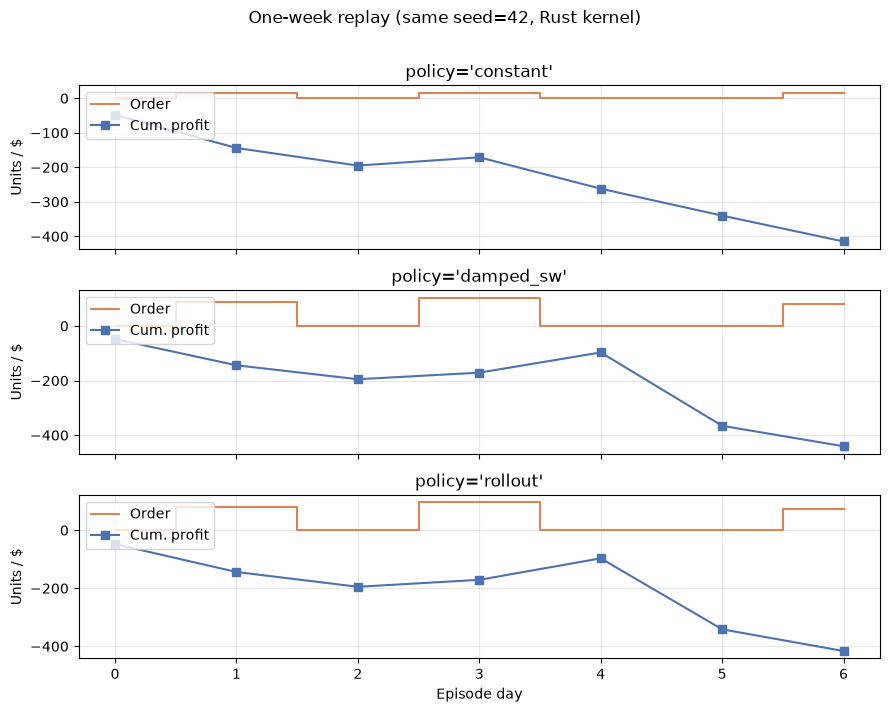

constant    week profit ≈ $-415.0
damped_sw   week profit ≈ $-440.5
rollout     week profit ≈ $-416.5


In [9]:
def session_config() -> dict:
    return {
        "shipments": smoke_cool_shipments(),
        **DEMO_BUDGETS,
        "enable_filter": True,
        "lead_time": 1,
        "obs_scenario": "P1",
    }


def replay_week(*, policy: str, root_seed: int = 42, n_days: int = 7, **act_kw) -> list[dict]:
    session = EngineSession()
    session.init(session_config(), seed=root_seed)
    rows = []
    cum = 0.0
    for _ in range(n_days):
        delta = session.act(policy=policy, alpha=ALPHA_TUNED, rho=0.8, **act_kw)
        day = delta["day"]
        dp = day_profit(
            SimpleNamespace(
                demand=int(day["demand"]),
                sales_total=int(day["sales_total"]),
                waste_total=int(day["waste_total"]),
            ),
            DEFAULT_PROFIT_COSTS,
        )
        cum += dp
        rows.append({
            "episode_day": int(delta["episode_day"]),
            "demand": int(day["demand"]),
            "order_qty": int(day["order_qty"]),
            "sales": int(day["sales_total"]),
            "waste": int(day["waste_total"]),
            "day_profit": dp,
            "cum_profit": cum,
            "on_hand": float(sum(delta["belief"]["lot_counts"])),
        })
    return rows


policies = [
    ("constant", {"order_qty": 16}),
    ("damped_sw", {}),
    ("rollout", {}),
]

replays = {name: replay_week(policy=name, **kw) for name, kw in policies}

fig, axes = plt.subplots(3, 1, figsize=(9, 7), sharex=True)
for ax, (name, days) in zip(axes, replays.items()):
    t = [d["episode_day"] for d in days]
    ax.step(t, [d["order_qty"] for d in days], where="mid", color="#DD8452", label="Order")
    ax.plot(t, [d["cum_profit"] for d in days], "s-", color="#4C72B0", label="Cum. profit")
    ax.set_ylabel("Units / $")
    ax.set_title(f"policy={name!r}")
    ax.legend(loc="upper left")
axes[-1].set_xlabel("Episode day")
fig.suptitle("One-week replay (same seed=42, Rust kernel)", y=1.01)
fig.tight_layout()
plt.show()

for name, days in replays.items():
    print(f"{name:10s}  week profit ≈ ${days[-1]['cum_profit']:.1f}")

## 10. Summary

| Idea | In code |
|------|---------|
| Newsvendor fractile | Motivation; `DEFAULT_PROFIT_COSTS` gives α* ≈ 0.57 |
| Naive base-stock | `open_loop_order(on_hand, S=60)` |
| Protection demand target | `protection_demand_quantile(α, params, protection_days=…)` |
| MWF calendar | `DEFAULT_ORDER_SCHEDULE` |
| Effective inventory | `effective_inventory(belief, …)` |
| Rung 0 age-blind | `CorrectedAgeBlindPolicy` |
| Damped SW | `DampedSurvivalWeightedPolicy` / `act(policy="damped_sw")` |
| Rollout improvement | `act(policy="rollout")` in Rust |
| Full closed loop | `EngineSession.init` → `act()` |

**Takeaway:** the controller is a base-stock family at heart — but the target `d*`
covers a **calendar protection window**, inventory is counted by **survival-weighted
effective units**, and rollout adds a **one-step lookahead** on top. All of that hot
path lives in the Rust/PyO3 kernel for speed.

Related notebooks: 06 (Ĩ + SW), 07 (α tuning), 08 (ladder + toy DP), 10 (CRN capstone).